In [1]:
#module DataBionicSwarm

#export Grid

"""
    Grid

Rectangular environment for the databots
Edges wrap left <> right and top <> bottom (Pac-Man style)
"""
struct Grid
    lines :: Int
    cols :: Int
    function Grid(lines::Int, cols::Int)
        lines >= 3 || error("Grid needs at least  lines, got $lines")
        cols >= 3 || error("Grid needs at least 3 cols, got $cols")
        new(lines, cols)
    end
end

"""
    make_grid(n) -> Grid

Make me an envrionment big enough for n bots to move around and 
self-organise without being cramped.
It creates an grid area which is ~3-5x larger than the n-amount of bots.
"""
function make_grid(n::Int; fill_ratio=0.2) :: Grid
    side = ceil(Int, sqrt(n * 0.2) * 4)
    side = isodd(side) ? side : side + 1
    return Grid(side, side)
end

"""
    valid_position(g, pos) -> Bool

Make sure a position can be placed within the grid.
Position is a complete number so it can have both the row-position and col-position
in a single value (real-part: row/x, imaginary-part: col/y)
"""
function valid_position(g::Grid, pos::ComplexF64) :: Bool
    r, c = Int(real(pos)), Int(imag(pos))
    return 1 <= r <= g.lines && 1 <= c <= g.cols
end



#end # module

#using .DatabionicSwarm
#println("Module loaded")

valid_position

In [2]:
g = Grid(9, 9)
#@show g

Grid(9, 9)

In [3]:
for n in [15, 50, 100, 500, 1000, 5000]
    g = make_grid(n)
    println("n=$n -> $(g.lines) x $(g.cols) = $(g.lines*g.cols) cells
        ($(round(g.lines*g.cols/n, digits=1))x data)"
    )
end

n=15 -> 7 x 7 = 49 cells
        (3.3x data)
n=50 -> 13 x 13 = 169 cells
        (3.4x data)
n=100 -> 19 x 19 = 361 cells
        (3.6x data)
n=500 -> 41 x 41 = 1681 cells
        (3.4x data)
n=1000 -> 57 x 57 = 3249 cells
        (3.2x data)
n=5000 -> 127 x 127 = 16129 cells
        (3.2x data)


In [4]:
# test a bit what is the effect of make_grid function
n= 150
fill_ratio=0.2
sqrt(n * 0.2) * 4
#sqrt(n / fill_ratio)

21.908902300206645

In [5]:
# create a coordinate as complete number and print
pos = ComplexF64(3, 7)

println("position : ", pos)
println("row      : ", Int(real(pos)))
println("col      : ", Int(imag(pos)))
println("valid?   : ", valid_position(g, pos))
println("(0,0)?   : ", valid_position(g, ComplexF64(0, 0)))

position : 3.0 + 7.0im
row      : 3
col      : 7
valid?   : true
(0,0)?   : false


In [6]:
# lets make a set of coordinates and test
occupied = Set([
        ComplexF64(1,1), 
        ComplexF64(3,7), 
        ComplexF64(9,9)
])

# using the '∈' operator we can check if a coordinate is in our set
println("(3,7) occupied? ", ComplexF64(3,7) ∈ occupied)   # true
println("(2,5) occupied? ", ComplexF64(2,5) ∈ occupied)   # false

(3,7) occupied? true
(2,5) occupied? false


In [7]:
"""
    toroidal_dist(g, a, b) -> Float64

Pac-Man distance between two points in the grid.
Positions are complete numbers so it contains both the row-position and col-position
in a single value (real-part: row/x, imaginary-part: col/y)
"""
function toroidal_dist(g::Grid, a::ComplexF64, b::ComplexF64) :: Float64
    dx = abs(real(a) - real(b))
    dy = abs(imag(a) - imag(b))
    dx = min(dx, g.lines - dx + 1)
    dy = min(dy, g.cols - dy + 1)
    return sqrt(dx^2 + dy^2)
end

"""
    toroidal_dist_matrix(g, positions) -> Matrix

Pac-Man distance between all bots as matrix.
"""
function toroidal_dist_matrix(g::Grid, positions::Vector{ComplexF64}) :: Matrix{Float64}
    n = length(positions)
    D = Matrix{Float64}(undef, n, n)
    for i in 1:n
        D[i, i] = 0.0
        for j in (i+1):n
            d = toroidal_dist(g, positions[i], positions[j])
            D[i, j] = d
            D[j, i] = d
        end
    end
    return D
end
    

toroidal_dist_matrix

In [8]:
g = Grid(9, 9)
cases = [
   ("no wrap",       ComplexF64(3,3), ComplexF64(5,6)),
   ("horiz wrap",    ComplexF64(5,1), ComplexF64(5,9)),
   ("vert wrap",     ComplexF64(1,5), ComplexF64(9,5)),
   ("corner wrap",   ComplexF64(1,1), ComplexF64(9,9)),
   ("same position", ComplexF64(4,4), ComplexF64(4,4)),
]
println("case              a             b             dist")
println("─"^55)
for (label, a, b) in cases
   d = toroidal_dist(g, a, b)
   println(
        rpad(label,18), 
        rpad(a,14), 
        rpad(b,14), 
        round(d, digits=4)
    )
end

case              a             b             dist
───────────────────────────────────────────────────────
no wrap           3.0 + 3.0im   5.0 + 6.0im   3.6056
horiz wrap        5.0 + 1.0im   5.0 + 9.0im   2.0
vert wrap         1.0 + 5.0im   9.0 + 5.0im   2.0
corner wrap       1.0 + 1.0im   9.0 + 9.0im   2.8284
same position     4.0 + 4.0im   4.0 + 4.0im   0.0


In [9]:
# Full 5-bot distance matrix
positions = [
   ComplexF64(1, 1),   # TL — top-left
   ComplexF64(5, 5),   # C  — centre
   ComplexF64(9, 9),   # BR — bottom-right (wraps close to TL)
   ComplexF64(1, 9),   # TR — top-right
   ComplexF64(9, 1),   # BL — bottom-left
]
D = toroidal_dist_matrix(g, positions)
labels = ["TL","C","BR","TR","BL"]
print(rpad("", 6))
for l in labels; print(rpad(l, 7)); end
println()
println("─"^41)
for i in 1:5
   print(rpad(labels[i], 6))
   for j in 1:5
       print(rpad(round(D[i,j], digits=2), 7))
   end
   println()
end

      TL     C      BR     TR     BL     
─────────────────────────────────────────
TL    0.0    5.66   2.83   2.0    2.0    
C     5.66   0.0    5.66   5.66   5.66   
BR    2.83   5.66   0.0    2.0    2.0    
TR    2.0    5.66   2.0    0.0    2.83   
BL    2.0    5.66   2.0    2.83   0.0    


In [10]:
# Unicode heatmap — wrap-around visible at the edges
g_vis  = Grid(11, 21)
origin = ComplexF64(6, 11)   # centre
blocks = [' ', '░', '▒', '▓', '█']
max_d  = toroidal_dist(g_vis, origin, ComplexF64(1, 1))
println("Distance field from centre — darker = closer")
println()
for r in 1:g_vis.lines
   for c in 1:g_vis.cols
       d   = toroidal_dist(g_vis, origin, ComplexF64(r, c))
       idx = 5 - clamp(ceil(Int, d / max_d * 4), 1, 4)
       print(blocks[idx + 1], " ")
   end
   println()
end

Distance field from centre — darker = closer

░ ░ ░ ░ ▒ ▒ ▒ ▒ ▓ ▓ ▓ ▓ ▓ ▒ ▒ ▒ ▒ ░ ░ ░ ░ 
░ ░ ░ ▒ ▒ ▒ ▒ ▓ ▓ ▓ ▓ ▓ ▓ ▓ ▒ ▒ ▒ ▒ ░ ░ ░ 
░ ░ ░ ▒ ▒ ▒ ▓ ▓ ▓ ▓ ▓ ▓ ▓ ▓ ▓ ▒ ▒ ▒ ░ ░ ░ 
░ ░ ▒ ▒ ▒ ▓ ▓ ▓ ▓ █ █ █ ▓ ▓ ▓ ▓ ▒ ▒ ▒ ░ ░ 
░ ░ ▒ ▒ ▒ ▓ ▓ ▓ █ █ █ █ █ ▓ ▓ ▓ ▒ ▒ ▒ ░ ░ 
░ ░ ▒ ▒ ▒ ▓ ▓ ▓ █ █ █ █ █ ▓ ▓ ▓ ▒ ▒ ▒ ░ ░ 
░ ░ ▒ ▒ ▒ ▓ ▓ ▓ █ █ █ █ █ ▓ ▓ ▓ ▒ ▒ ▒ ░ ░ 
░ ░ ▒ ▒ ▒ ▓ ▓ ▓ ▓ █ █ █ ▓ ▓ ▓ ▓ ▒ ▒ ▒ ░ ░ 
░ ░ ░ ▒ ▒ ▒ ▓ ▓ ▓ ▓ ▓ ▓ ▓ ▓ ▓ ▒ ▒ ▒ ░ ░ ░ 
░ ░ ░ ▒ ▒ ▒ ▒ ▓ ▓ ▓ ▓ ▓ ▓ ▓ ▒ ▒ ▒ ▒ ░ ░ ░ 
░ ░ ░ ░ ▒ ▒ ▒ ▒ ▓ ▓ ▓ ▓ ▓ ▒ ▒ ▒ ▒ ░ ░ ░ ░ 


In [11]:
11 / 2

5.5

In [12]:
11 ÷ 2

5

In [13]:
struct PolarGrid
    rmin :: Int  # minimum annealing radius
    rmax :: Int  # maximum annealing radius

    # for each radius R: the set of (dr, dc) offsets that land on that ring
    # rings[R] = Vector of complete offsets (real=delta-row, imag=delta-col)
    rings :: Vector{Vector{ComplexF64}}
end

"""
    setup_polar_grid(g) -> PolarGrid

Result are ring coordinates for different r.
Number of r's and range of r's are based on grid size.
Each x below is a valid dx,dy for that particular r (first 3 radi are still squares).

r = 1 (8 positions)
x x x
x o x
x x x

r = 2 (16 positions)
x x x x x
x       x
x   o   x
x       x
x x x x x
"""
function setup_polar_grid(g::Grid) :: PolarGrid
    # maximum radius can maximum be half of the grid
    # minimum radius adds 1, if grid width adds 20
    # ÷ gives the round down Integer, different compare to /
    rmax = g.lines ÷ 2
    rmin = max(1, rmax ÷ 10)

    # println("rmin: ", rmin, " rmax: ", rmax)

    rings = Vector{Vector{ComplexF64}}(undef, rmax)

    # TODO: double check if this shall not be rmin:rmax
    for r in 1:rmax
        offsets = ComplexF64[]
        # 
        for dr in -r:r
            for dc in -r:r
                dist = sqrt(dr^2 + dc^2)
                
                if floor(Int, dist) == r
                    push!(offsets, ComplexF64(dr, dc))
                    # println("dr: ", dr, " dc: ", dc, " dist: ", dist)
                end
            end
        end
        rings[r] = offsets
    end

    return PolarGrid(rmin, rmax, rings)
end

setup_polar_grid

In [14]:
g = Grid(9, 9)
pg = setup_polar_grid(g)
pg.rmin, pg.rmax, length(pg.rings)

(1, 4, 4)

In [15]:
"""
    allowed_positions(pg, g, bot_pos, R) -> Vector

Given a position of a bot, returns the possible coordinates
it can go to in the main grid (in Pac-Man style) given a search radius.
It is able to do so using the delta coords for each radi of computed polar grids 
"""
function allowed_positions(pg::PolarGrid, g::Grid, 
        bot_pos::ComplexF64, R::Int) :: Vector{ComplexF64}
    row = real(bot_pos)
    col = imag(bot_pos)
    result = ComplexF64[]

    for offset in pg.rings[R]
        # eg for a grid of 3 by 3 and a bot position on 1,1
        # for offset -1 (do one step left) will return in a 
        # new_row of 3 (calculate: mod(1 - 1 + -1, 3) + 1)
        # like Pac-Man
        new_row = mod(row - 1 + real(offset), g.lines) + 1
        new_col = mod(col - 1 + imag(offset), g.cols) + 1
        push!(result, ComplexF64(new_row, new_col))
    end
    
    return result
end

allowed_positions

In [16]:
# Visual — show the ring on the grid as ASCII
function show_ring(g, pg, bot, R)
    reachable = Set(allowed_positions(pg, g, bot, R))
    br, bc = Int(real(bot)), Int(imag(bot))
    println("Grid $(g.lines)×$(g.cols)  bot=($(br),$(bc))  R=$R")
    println()
    for r in 1:g.lines
        for c in 1:g.cols
            p = ComplexF64(r, c)
            if p == bot
                print(" ● ")
            elseif p ∈ reachable
                print(" ○ ")
            else
                print(" · ")
            end
        end
        println()
    end
end

show_ring(g, pg, ComplexF64(5,5), 1)

Grid 9×9  bot=(5,5)  R=1

 ·  ·  ·  ·  ·  ·  ·  ·  · 
 ·  ·  ·  ·  ·  ·  ·  ·  · 
 ·  ·  ·  ·  ·  ·  ·  ·  · 
 ·  ·  ·  ○  ○  ○  ·  ·  · 
 ·  ·  ·  ○  ●  ○  ·  ·  · 
 ·  ·  ·  ○  ○  ○  ·  ·  · 
 ·  ·  ·  ·  ·  ·  ·  ·  · 
 ·  ·  ·  ·  ·  ·  ·  ·  · 
 ·  ·  ·  ·  ·  ·  ·  ·  · 


In [17]:
show_ring(g, pg, ComplexF64(5,5), 3)

Grid 9×9  bot=(5,5)  R=3

 ·  ·  ·  ·  ·  ·  ·  ·  · 
 ·  ·  ○  ○  ○  ○  ○  ·  · 
 ·  ○  ·  ·  ·  ·  ·  ○  · 
 ·  ○  ·  ·  ·  ·  ·  ○  · 
 ·  ○  ·  ·  ●  ·  ·  ○  · 
 ·  ○  ·  ·  ·  ·  ·  ○  · 
 ·  ○  ·  ·  ·  ·  ·  ○  · 
 ·  ·  ○  ○  ○  ○  ○  ·  · 
 ·  ·  ·  ·  ·  ·  ·  ·  · 


In [18]:
# Corner bot — wrap should give same ring shape
show_ring(g, pg, ComplexF64(1,1), 2)

Grid 9×9  bot=(1,1)  R=2

 ●  ·  ○  ·  ·  ·  ·  ○  · 
 ·  ·  ○  ·  ·  ·  ·  ○  · 
 ○  ○  ○  ·  ·  ·  ·  ○  ○ 
 ·  ·  ·  ·  ·  ·  ·  ·  · 
 ·  ·  ·  ·  ·  ·  ·  ·  · 
 ·  ·  ·  ·  ·  ·  ·  ·  · 
 ·  ·  ·  ·  ·  ·  ·  ·  · 
 ○  ○  ○  ·  ·  ·  ·  ○  ○ 
 ·  ·  ○  ·  ·  ·  ·  ○  · 


In [22]:
using Random

In [23]:
"""
    Swarm

The population of DataBots on the grid.

Fields
------
- `pos`      : Vector{ComplexF64} — one position per bot (real=row, imag=col)
- `occupied` : Set{ComplexF64}    — fast O(1) lookup of taken cells
- `n`        : number of bots (== number of data points)

length(pos) == n  cannot be equal to length(occupied) == n
i.e. no two bots share a cell at any time.
"""
struct Swarm
    pos :: Vector{ComplexF64}
    occupied :: Set{ComplexF64}
    n :: Int
end

"""
    init_swarm(g, n, seed) -> Swarm

We shuffle all available coordinates in the grid.
Take the first n coordinates; these can be used to place the bots.
"""
function init_swarm(g::Grid, n::Int; seed::Union{Int, Nothing}=nothing) :: Swarm
    n <= g.lines * g.cols || error("Too many bots ($n) for grid $(g.lines)×$(g.cols)")

    rng = isnothing(seed) ? Random.default_rng() : Random.MersenneTwister(seed)

    all_cells = [ComplexF64(r, c)
        for r in 1:g.lines
            for c in 1:g.cols]

    shuffle!(rng, all_cells)
    chosen = all_cells[1:n]

    return Swarm(chosen, Set(chosen), n)
end

"""
    move_bot!(swarm, idx, new_pos)

Based on the existing positions in swarm, 
we add the new position and remove the previous position.
If the new position is taken already, then the positions merge.
We combine it into a single function so they don't deviate
"""
function move_bot!(swarm::Swarm, idx::Int, new_pos::ComplexF64)
    old_pos = swarm.pos[idx]
    delete!(swarm.occupied, old_pos)
    swarm.pos[idx] = new_pos
    push!(swarm.occupied, new_pos)
end

"""
    is_free(swarm, pos) -> Bool

Check if position is not in set of occupied cells. 
If position is not in existing swarm positions, than return true
"""
function is_free(swarm::Swarm, pos::ComplexF64) :: Bool
    return pos ∉ swarm.occupied
end

is_free

In [24]:
g = make_grid(20)
println("Grid: $(g.lines) × $(g.cols) = $(g.lines*g.cols) cells for 20 bots")

Grid: 9 × 9 = 81 cells for 20 bots


In [25]:
# Reproducible init with seed
swarm = init_swarm(g, 20, seed=42)
println("Bots placed : ", swarm.n)
println("Occupied    : ", length(swarm.occupied))
println("First 5 pos : ", swarm.pos[1:5])

Bots placed : 20
Occupied    : 20
First 5 pos : ComplexF64[3.0 + 8.0im, 8.0 + 6.0im, 3.0 + 7.0im, 4.0 + 9.0im, 7.0 + 1.0im]


In [26]:
swarm.occupied

Set{ComplexF64} with 20 elements:
  4.0 + 1.0im
  8.0 + 6.0im
  3.0 + 7.0im
  8.0 + 2.0im
  9.0 + 1.0im
  2.0 + 8.0im
  9.0 + 8.0im
  4.0 + 6.0im
  5.0 + 9.0im
  3.0 + 8.0im
  8.0 + 9.0im
  7.0 + 1.0im
  9.0 + 3.0im
  7.0 + 8.0im
  4.0 + 9.0im
  5.0 + 6.0im
  8.0 + 8.0im
  5.0 + 2.0im
  7.0 + 3.0im
  1.0 + 5.0im

In [27]:
# is_free / move_bot
println("Cell (1,1) free? ", is_free(swarm, ComplexF64(1,1)))

Cell (1,1) free? true


In [28]:
free_cell = ComplexF64(1,1)

1.0 + 1.0im

In [29]:
old = swarm.pos[1]
old

3.0 + 8.0im

In [30]:
move_bot!(swarm, 1, free_cell)

Set{ComplexF64} with 20 elements:
  4.0 + 1.0im
  1.0 + 1.0im
  8.0 + 6.0im
  3.0 + 7.0im
  8.0 + 2.0im
  9.0 + 1.0im
  2.0 + 8.0im
  9.0 + 8.0im
  4.0 + 6.0im
  5.0 + 9.0im
  8.0 + 9.0im
  7.0 + 1.0im
  9.0 + 3.0im
  7.0 + 8.0im
  4.0 + 9.0im
  5.0 + 6.0im
  8.0 + 8.0im
  5.0 + 2.0im
  7.0 + 3.0im
  1.0 + 5.0im

In [31]:
# Visual — show bot positions on the grid
function show_swarm(g, swarm)
    println("Grid $(g.lines)×$(g.cols)  $(swarm.n) bots\n")
    for r in 1:g.lines
        for c in 1:g.cols
            print(ComplexF64(r,c) ∈ swarm.occupied ? " ● " : " · ")
        end
        println()
    end
end

show_swarm(g, swarm)

Grid 9×9  20 bots

 ●  ·  ·  ·  ●  ·  ·  ·  · 
 ·  ·  ·  ·  ·  ·  ·  ●  · 
 ·  ·  ·  ·  ·  ·  ●  ·  · 
 ●  ·  ·  ·  ·  ●  ·  ·  ● 
 ·  ●  ·  ·  ·  ●  ·  ·  ● 
 ·  ·  ·  ·  ·  ·  ·  ·  · 
 ●  ·  ●  ·  ·  ·  ·  ●  · 
 ·  ●  ·  ·  ·  ●  ·  ●  ● 
 ●  ·  ●  ·  ·  ·  ·  ●  · 


In [32]:
"""
    normalise_matrix(D) -> Matrix{Float64}

Scale a distance matrix to [0,1] by dividing by its maximum.
Applied to both D_data and D_grid before stress is computed
so the two matrices live on the same scale.
"""
function normalise_matrix(D::Matrix{Float64}) :: Matrix{Float64}
    m = maximum(D)
    m == 0.0 && return D
    return D ./ m
end

normalise_matrix

In [33]:
function stress(D_data::Matrix{Float64}, D_grid::Matrix{Float64})
    size(D_data) == size(D_grid) || error("Distance mastrices must have the same size")

    n = size(D_data, 1)
    nd = normalise_matrix(D_data)
    ng = normalise_matrix(D_grid)

    total = 0.0
    npairs = 0
    for i in 1:n
        for j in (i+1):n
            diff = nd[i,j] - ng[i,j]
            total += diff^2  # add a power to amplify stress for larger distances
            npairs += 1
        end
    end

    return total / npairs
end

"""
    stress_if_moved(D_data, g, swarm, bot_idx, candidate) -> Float64

Compute stress for the hypothetical state where bot_idx
has moved to candidate — without actually moving it.
Used in the jump decision loop.
"""
function stress_if_moved(D_data::Matrix{Float64},
        g::Grid,
        swarm::Swarm,
        bot_idx::Int,
        candidate::ComplexF64) :: Float64

    tmp = copy(swarm.pos)
    tmp[bot_idx] = candidate
    D_grid = toroidal_dist_matrix(g, tmp)
    return stress(D_data, D_grid)
end

stress_if_moved

In [34]:
g = Grid(3,5)
tdm = toroidal_dist_matrix(g, [ComplexF64(2,1), ComplexF64(3,5)])
s = size(tdm, 1)
print(s)
tdm

2

2×2 Matrix{Float64}:
 0.0      2.23607
 2.23607  0.0

In [35]:
# Toy example: 4 data points in two clear clusters
# Points 1,2 are close · Points 3,4 are close · clusters far apart
D_data = [0.0  0.2  0.9  0.8;
          0.2  0.0  0.8  0.9;
          0.9  0.8  0.0  0.2;
          0.8  0.9  0.2  0.0]

println("D_data (hand-crafted clusters):")
display(D_data)

D_data (hand-crafted clusters):


4×4 Matrix{Float64}:
 0.0  0.2  0.9  0.8
 0.2  0.0  0.8  0.9
 0.9  0.8  0.0  0.2
 0.8  0.9  0.2  0.0

In [36]:
# Case 1: perfect layout — grid distances mirror data distances
g = Grid(5, 5)

# Cluster A: bots 1,2 placed close together
# Cluster B: bots 3,4 placed far away
pos_perfect = [
    ComplexF64(1, 1),   # bot 1 ─┐ cluster A
    ComplexF64(1, 2),   # bot 2 ─┘
    ComplexF64(5, 5),   # bot 3 ─┐ cluster B
    ComplexF64(5, 4),   # bot 4 ─┘
]
D_grid_perfect = toroidal_dist_matrix(g, pos_perfect)
s_perfect = stress(D_data, D_grid_perfect)
println("Stress (good layout) : ", round(s_perfect, digits=4))

Stress (good layout) : 0.0206


In [37]:
D_grid_perfect

4×4 Matrix{Float64}:
 0.0      1.0      2.82843  3.60555
 1.0      0.0      3.60555  2.82843
 2.82843  3.60555  0.0      1.0
 3.60555  2.82843  1.0      0.0

In [38]:
# Case 2: bad layout — clusters mixed up on the grid
pos_bad = [
    ComplexF64(1, 1),   # bot 1 ─┐ cluster A split
    ComplexF64(5, 5),   # bot 2 ─┘ across the grid
    ComplexF64(1, 2),   # bot 3 ─┐ cluster B crammed
    ComplexF64(1, 3),   # bot 4 ─┘ next to bot 1
]
D_grid_bad = toroidal_dist_matrix(g, pos_bad)
s_bad = stress(D_data, D_grid_bad)
println("Stress (bad layout)  : ", round(s_bad, digits=4))
println()
println("Good < Bad? ", s_perfect < s_bad, "  ✓")

Stress (bad layout)  : 0.1686

Good < Bad? true  ✓


In [ ]:
?Swarm

In [39]:
# stress_if_moved — peek at a candidate without committing
swarm = Swarm(pos_bad, Set(pos_bad), 4)
current_stress = stress(D_data, toroidal_dist_matrix(g, swarm.pos))

# What if we move bot 2 from (5,5) to (1,2)?
candidate = ComplexF64(2, 1)
new_stress = stress_if_moved(D_data, g, swarm, 2, candidate)

println("Current stress       : ", round(current_stress, digits=4))
println("Stress if bot 2 moves: ", round(new_stress, digits=4))
println("Worth jumping?       : ", new_stress < current_stress)

Current stress       : 0.1686
Stress if bot 2 moves: 0.0788
Worth jumping?       : true


In [40]:
# Stress should be 0 when layout is identical to data distances
D_identity = toroidal_dist_matrix(g, pos_perfect)
s_identity = stress(D_identity, D_identity)
println("Stress (identical matrices): ", s_identity)  # → 0.0

Stress (identical matrices): 0.0


In [41]:
D_identity

4×4 Matrix{Float64}:
 0.0      1.0      2.82843  3.60555
 1.0      0.0      3.60555  2.82843
 2.82843  3.60555  0.0      1.0
 3.60555  2.82843  1.0      0.0

In [42]:
using Statistics

In [43]:
function swarm_epoch!(swarm::Swarm,
    D_data::Matrix{Float64},
    g::Grid,
    pg::PolarGrid,
    R::Int;
    rng=Random.default_rng()) :: Tuple{Int, Float64}

    # fraction of bots that get to jump shrinks with R
    # large R -> explore widely, small R -> fine-tune
    
    jump_fraction = 0.05 + 0.45 * (R - pg.rmin) / max(1, pg.rmax - pg.rmin)
    n_candidates = max(1, round(Int, swarm.n * jump_fraction))

    bot_order = shuffle(rng, 1:swarm.n)
    active = bot_order[1:n_candidates]
    
    n_jumped = 0

    for idx in active
        ring = allowed_positions(pg, g, swarm.pos[idx], R)
        isempty(ring) && continue

        candidates = ring[rand(rng, 1:length(ring), min(4, length(ring)))]

        free_candidates = filter(c -> is_free(swarm, c), candidates)
        isempty(free_candidates) && continue

        current_s = stress_if_moved(D_data, g, swarm, idx, swarm.pos[idx])
        best_pos = swarm.pos[idx]
        best_s = current_s

        for cand in free_candidates
            s = stress_if_moved(D_data, g, swarm, idx, cand)
            if s < best_s
                best_s = s
                best_pos = cand
            end
        end

        # jump if we found something better
        if best_pos != swarm.pos[idx]
            move_bot!(swarm, idx, best_pos)
            n_jumped += 1
        end
    end

    # end with computing overall stress after all moves in this epoch
    D_grid = toroidal_dist_matrix(g, swarm.pos)
    current_stress = stress(D_data, D_grid)

    return (n_jumped, current_stress)
end


function swarm_radius!(swarm::Swarm,
        D_data::Matrix{Float64},
        g::Grid,
        pg::PolarGrid,
        R::Int;
        epsilon::Float64=0.01,
        max_epochs::Int=200,
        window::Int=10,
        rng=Random.default_rng()) :: Vector{Float64}

    history = Float64[]

    for epoch in 1:max_epochs
        n_jumped, s = swarm_epoch!(swarm, D_data, g, pg, R; rng)
        push!(history, s)

        # we evaluate after running at least 'window' epochs
        if length(history) >= window
            recent = history[end-window+1:end]
            slope = _linear_slope(recent)

            if abs(slope) < epsilon
                break
            end
        end
    end

    return history
end

function _linear_slope(ys::Vector{Float64}) :: Float64
    n = length(ys)
    xs = Float64.(1:n)
    mean_xs = mean(xs)
    mean_ys = mean(ys)
    num = sum((xs .- mean_xs) .* (ys .- mean_ys))
    denom = sum((xs .- mean_xs) .^ 2)
    denom == 0.0 && return 0.0
    return num / denom
end

_linear_slope (generic function with 1 method)

In [44]:
R = 3
rmin = 2
rmax = 20
n = 20
jump_fraction = 0.05 + 0.45 * (R - rmin) / max(1, rmax - rmin)
n_candidates = max(1, round(Int, n * jump_fraction))
n_candidates

2

In [45]:
n_candidates = 3 
bot_order = shuffle(Random.default_rng(), 1:20)
active = bot_order[1:n_candidates]
print(active)
bot_order

[17, 2, 9]

20-element Vector{Int64}:
 17
  2
  9
 10
 19
 15
 14
 13
  8
  6
 16
 20
  3
  4
 18
 12
  5
  1
  7
 11

In [46]:
ys = Float64[6,4,3]
xs = Float64.(1:3)

mean_xs = mean(xs)
mean_ys = mean(ys)
num = sum((xs .- mean_xs) .* (ys .- mean_ys))
denum = sum((xs .- mean_xs) .^ 2)



2.0

In [47]:
(xs .- mean_xs) .* (ys .- mean_ys)

3-element Vector{Float64}:
 -1.666666666666667
 -0.0
 -1.333333333333333

In [48]:
xs .- mean_xs

3-element Vector{Float64}:
 -1.0
  0.0
  1.0

In [49]:
# Two clear clusters — 3 points each
D_data = [0.0  0.1  0.2  0.9  0.8  0.9;
          0.1  0.0  0.1  0.8  0.9  0.8;
          0.2  0.1  0.0  0.9  0.8  0.9;
          0.9  0.8  0.9  0.0  0.1  0.2;
          0.8  0.9  0.8  0.1  0.0  0.1;
          0.9  0.8  0.9  0.2  0.1  0.0]

g     = make_grid(6)
pg    = setup_polar_grid(g)
swarm = init_swarm(g, 6, seed=42)

println("Grid  : $(g.lines) × $(g.cols)")
println("Rmin  : $(pg.rmin)  Rmax : $(pg.rmax)")

Grid  : 5 × 5
Rmin  : 1  Rmax : 2


In [50]:
# Single epoch at Rmax
n_jumped, s = swarm_epoch!(swarm, D_data, g, pg, pg.rmax, rng=Random.MersenneTwister(1))
println("Epoch at R=$(pg.rmax): jumped=$n_jumped  stress=$(round(s, digits=4))")

Epoch at R=2: jumped=0  stress=0.1522


In [51]:
# Run full radius — watch stress converge
history = swarm_radius!(swarm, D_data, g, pg, pg.rmax,
                        rng=Random.MersenneTwister(42))

println("Epochs until convergence: $(length(history))")
println("Stress start : $(round(history[1],   digits=4))")
println("Stress end   : $(round(history[end], digits=4))")
println()
println("Stress per epoch:")
for (i, s) in enumerate(history)
    bar = "█" ^ round(Int, s * 40)
    println("  epoch $(lpad(i,3)) | $(rpad(bar,40)) | $(round(s, digits=4))")
end

Epochs until convergence: 10
Stress start : 0.0906
Stress end   : 0.0419

Stress per epoch:
  epoch   1 | ████                                     | 0.0906
  epoch   2 | ████                                     | 0.0906
  epoch   3 | ████                                     | 0.0906
  epoch   4 | ███                                      | 0.0848
  epoch   5 | ██                                       | 0.0525
  epoch   6 | ██                                       | 0.0463
  epoch   7 | ██                                       | 0.0463
  epoch   8 | ██                                       | 0.0463
  epoch   9 | ██                                       | 0.0419
  epoch  10 | ██                                       | 0.0419


In [52]:
flat    = [0.5, 0.5, 0.5, 0.5, 0.5]
falling = [0.9, 0.7, 0.5, 0.3, 0.1]
println("Slope of flat series    : ", round(_linear_slope(flat),    digits=4))  # ≈ 0
println("Slope of falling series : ", round(_linear_slope(falling), digits=4))  # negative

Slope of flat series    : 0.0
Slope of falling series : -0.2


In [53]:
using Printf

In [54]:
struct PswarmResult
    positions      :: Vector{ComplexF64}
    stress_history :: Vector{Float64}
    radius_history :: Vector{Int}
    grid           :: Grid
    polar          :: PolarGrid
    final_stress   :: Float64
end

function pswarm!(D_data::Matrix{Float64};
        seed::Union{Int, Nothing}=nothing,
        #fill_ratio::Float64=0.2,
        epsilon::Float64=0.01,
        max_epochs::Int=200,
        verbose::Bool=true) :: PswarmResult

    n = size(D_data, 1)
    size(D_data, 2) == n || error("D_data must be a square")

    g = make_grid(n)
    pg = setup_polar_grid(g)
    rng = isnothing(seed) ? Random.default.rng() : Random.MersenneTwister(seed)

    verbose && println("Grid     : $(g.lines) × $(g.cols) = $(g.lines*g.cols) cells")
    verbose && println("Bots     : $n")
    verbose && println("Rmax     : $(pg.rmax)  Rmin : $(pg.rmin)")
    verbose && println()

    swarm = init_swarm(g, n; seed)

    all_stress = Float64[]
    all_radii = Int[]

    # from large radii to small radii
    for R in pg.rmax:-1:pg.rmin
        history = swarm_radius!(swarm, D_data, g, pg, R;
            epsilon, max_epochs, rng)

        append!(all_stress, history)
        append!(all_radii, fill(R, length(history)))

        if verbose
            @printf("R=%2d  epochs=%3d  stress=%.4f\n",
                R, length(history), history[end])
        end
    end

    final_s = stress(D_data, toroidal_dist_matrix(g, swarm.pos))

    verbose && println()
    verbose && println("Done. Final stress : $(round(final_s, digits=4))")

    return PswarmResult(
        copy(swarm.pos),
        all_stress,
        all_radii,
        g,
        pg,
        final_s
    )
end


pswarm! (generic function with 1 method)

In [55]:
fill(10, 2)

2-element Vector{Int64}:
 10
 10

In [56]:
# ── Toy dataset: 6 points, 2 clear clusters ──────────
D_data = [0.0  0.1  0.2  0.9  0.8  0.9;
          0.1  0.0  0.1  0.8  0.9  0.8;
          0.2  0.1  0.0  0.9  0.8  0.9;
          0.9  0.8  0.9  0.0  0.1  0.2;
          0.8  0.9  0.8  0.1  0.0  0.1;
          0.9  0.8  0.9  0.2  0.1  0.0]

result = pswarm!(D_data, seed=42, verbose=true)
print()

Grid     : 5 × 5 = 25 cells
Bots     : 6
Rmax     : 2  Rmin : 1

R= 2  epochs= 10  stress=0.0419
R= 1  epochs= 10  stress=0.0399

Done. Final stress : 0.0399


In [57]:
# Final positions — cluster A (1-3) and cluster B (4-6)
# should be spatially separated on the grid
println("Final bot positions:")
for (i, pos) in enumerate(result.positions)
    cluster = i <= 3 ? "A" : "B"
    println("  bot $i (cluster $cluster) → row=$(Int(real(pos))) col=$(Int(imag(pos)))")
end

Final bot positions:
  bot 1 (cluster A) → row=1 col=4
  bot 2 (cluster A) → row=1 col=5
  bot 3 (cluster A) → row=2 col=4
  bot 4 (cluster B) → row=5 col=1
  bot 5 (cluster B) → row=5 col=2
  bot 6 (cluster B) → row=3 col=1


In [58]:
# Stress history across all radii
println("Total epochs across all radii: ", length(result.stress_history))
println("Stress journey:")
for (i, (s, r)) in enumerate(zip(result.stress_history, result.radius_history))
    bar = "█" ^ round(Int, s * 50)
    println("  ep=$(lpad(i,3)) R=$(lpad(r,2)) | $(rpad(bar,50)) | $(round(s,digits=4))")
end

Total epochs across all radii: 20
Stress journey:
  ep=  1 R= 2 | █████                                              | 0.0906
  ep=  2 R= 2 | █████                                              | 0.0906
  ep=  3 R= 2 | █████                                              | 0.0906
  ep=  4 R= 2 | ████                                               | 0.0848
  ep=  5 R= 2 | ███                                                | 0.0525
  ep=  6 R= 2 | ██                                                 | 0.0463
  ep=  7 R= 2 | ██                                                 | 0.0463
  ep=  8 R= 2 | ██                                                 | 0.0463
  ep=  9 R= 2 | ██                                                 | 0.0419
  ep= 10 R= 2 | ██                                                 | 0.0419
  ep= 11 R= 1 | ██                                                 | 0.0419
  ep= 12 R= 1 | ██                                                 | 0.0406
  ep= 13 R= 1 | ██                    

In [59]:
# Visual — final layout on the grid
function show_result(result, labels)
    g = result.grid
    # Map position → bot index
    pos_to_bot = Dict(pos => i for (i, pos) in enumerate(result.positions))
    println("Final layout  (stress=$(round(result.final_stress, digits=4)))\n")
    for r in 1:g.lines
        for c in 1:g.cols
            p = ComplexF64(r, c)
            if haskey(pos_to_bot, p)
                print(" $(labels[pos_to_bot[p]]) ")
            else
                print(" · ")
            end
        end
        println()
    end
end

# A B C = cluster 1 · X Y Z = cluster 2
show_result(result, ["A","B","C","X","Y","Z"])

Final layout  (stress=0.0399)

 ·  ·  ·  A  B 
 ·  ·  ·  C  · 
 Z  ·  ·  ·  · 
 ·  ·  ·  ·  · 
 X  Y  ·  ·  · 


In [60]:
# Bigger test — iris-like: 3 clusters of 5 points each
using Random
Random.seed!(99)

function make_cluster_distances(n_clusters, cluster_size; within=0.15, between=0.85)
    n = n_clusters * cluster_size
    D = zeros(n, n)
    for i in 1:n, j in 1:n
        i == j && continue
        same = ceil(Int, i/cluster_size) == ceil(Int, j/cluster_size)
        D[i,j] = same ? within + rand()*0.1 : between + rand()*0.1
    end
    # make symmetric
    for i in 1:n, j in 1:n
        D[i,j] = (D[i,j] + D[j,i]) / 2
    end
    return D
end

D_iris = make_cluster_distances(3, 5)
result2 = pswarm!(D_iris, seed=7, verbose=true)
print()

Grid     : 7 × 7 = 49 cells
Bots     : 15
Rmax     : 3  Rmin : 1

R= 3  epochs= 10  stress=0.0789
R= 2  epochs= 10  stress=0.0659
R= 1  epochs= 10  stress=0.0656

Done. Final stress : 0.0656


In [61]:
# Show cluster separation on grid
cluster_labels = [string(ceil(Int, i/5)) for i in 1:15]
show_result(result2, cluster_labels)

Final layout  (stress=0.0656)

 ·  ·  ·  ·  ·  ·  · 
 ·  ·  ·  ·  1  1  1 
 2  2  ·  ·  1  1  · 
 2  ·  ·  ·  ·  ·  · 
 2  ·  ·  ·  ·  ·  · 
 2  ·  ·  3  ·  ·  · 
 ·  ·  3  3  3  3  · 


In [62]:
function projection_data(result::PswarmResult)
    rows = Int.(real.(result.positions))
    cols = Int.(imag.(result.positions))
    return rows, cols
end

function umatrix(result::PswarmResult) :: Matrix{Float64}
    g = result.grid
    U = fill(NaN, g.lines, g.cols)
    pos = result.positions

    cell_to_bot = Dict(p => i for (i, p) in enumerate(pos))

    neighbours = [
        ComplexF64(-1,0), ComplexF64(1,0),
        ComplexF64(0,-1), ComplexF64(0,1)
    ]

    D_grid = toroidal_dist_matrix(g, pos)

    for (i, p) in enumerate(pos)
        r, c = real(p), imag(p)
        dists = Float64[]

        for offset in neighbours
            nr = mod(r - 1 + real(offset), g.lines) + 1
            nc = mod(c - 1 + imag(offset), g.cols) + 1
            neighbour_cell = ComplexF64(nr, nc)

            if haskey(cell_to_bot, neighbour_cell)
                j = cell_to_bot[neighbour_cell]
                push!(dists, D_grid[i, j])
            end
        end

        isempty(dists) || (U[Int(r), Int(c)] = mean(dists))
    end

    return U
end

umatrix (generic function with 1 method)

In [63]:
#?haskey

In [64]:
function make_cluster_distances(n_clusters, cluster_size;
                                 within=0.15, between=0.85)
    n = n_clusters * cluster_size
    D = zeros(n, n)
    for i in 1:n, j in 1:n
        i == j && continue
        same = ceil(Int, i/cluster_size) == ceil(Int, j/cluster_size)
        D[i,j] = same ? within + rand()*0.1 : between + rand()*0.1
    end
    for i in 1:n, j in 1:n
        D[i,j] = (D[i,j] + D[j,i]) / 2
    end
    return D
end

Random.seed!(99)
D = make_cluster_distances(3, 5)

15×15 Matrix{Float64}:
 0.0       0.215922  0.182719  0.192801  …  0.876921  0.900795  0.866787
 0.225242  0.0       0.208925  0.212965     0.918662  0.875484  0.896082
 0.191904  0.199318  0.0       0.212321     0.913301  0.898192  0.901063
 0.203088  0.225431  0.20568   0.0          0.913771  0.880904  0.938777
 0.222875  0.223939  0.216407  0.201301     0.883152  0.894782  0.893708
 0.903589  0.874589  0.92938   0.906868  …  0.927041  0.886206  0.92858
 0.903028  0.876811  0.864735  0.918263     0.908615  0.89626   0.906222
 0.932566  0.875754  0.911011  0.8771       0.885088  0.903805  0.863042
 0.885501  0.910387  0.913253  0.880364     0.912572  0.934007  0.90201
 0.910876  0.853739  0.88802   0.928997     0.891393  0.907295  0.93012
 0.905651  0.916822  0.927206  0.914762  …  0.186757  0.226348  0.178276
 0.929008  0.91544   0.891924  0.909589     0.174897  0.203313  0.227879
 0.887586  0.912871  0.91049   0.898275     0.0       0.185489  0.175383
 0.885037  0.869583  0.877281  

In [65]:
result = pswarm!(D, seed=42, verbose=true)
print()

Grid     : 7 × 7 = 49 cells
Bots     : 15
Rmax     : 3  Rmin : 1

R= 3  epochs= 10  stress=0.0728
R= 2  epochs= 10  stress=0.0721
R= 1  epochs= 10  stress=0.0718

Done. Final stress : 0.0718


In [66]:
rows, cols = projection_data(result)

# Cluster labels and colours
n_per_cluster = 5
cluster_ids   = ceil.(Int, (1:15) ./ n_per_cluster)
palette       = [:tomato, :steelblue, :seagreen]
colors        = palette[cluster_ids]
labels        = ["Cluster $(c)" for c in cluster_ids]
print()

In [67]:
using Plots

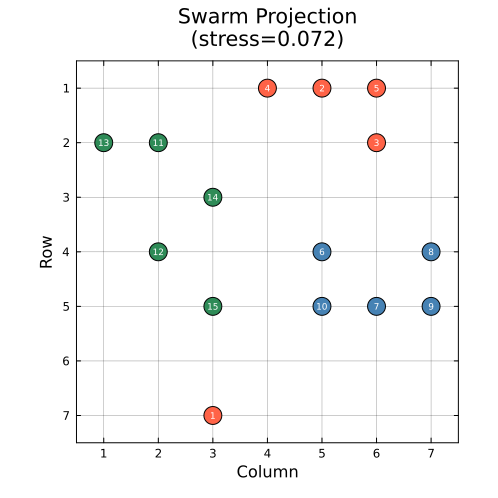

In [68]:
scatter(cols, rows,               # x=col, y=row (matrix convention)
    color       = colors,
    markersize  = 10,
    markerstroke = stroke(1, :white),
    xlabel      = "Column",
    ylabel      = "Row",
    title       = "Swarm Projection\n(stress=$(round(result.final_stress, digits=3)))",
    yflip       = true,           # row 1 at top like a matrix
    legend      = false,
    xlims       = (0.5, result.grid.cols + 0.5),
    ylims       = (0.5, result.grid.lines + 0.5),
    aspect_ratio = :equal,
    framestyle  = :box,
    grid        = true,
    gridalpha   = 0.2,
    size        = (500, 500)
)

# Add bot index annotations
for (i, (r, c)) in enumerate(zip(rows, cols))
    annotate!(c, r, text(string(i), 6, :white, :center))
end

plot!()

In [ ]:
U = umatrix(result)

In [ ]:
heatmap(U,
    color       = :RdYlGn,      # green = high distance = boundary
    title       = "U-Matrix\n(green = cluster boundary)",
    xlabel      = "Column",
    ylabel      = "Row",
    yflip       = true,
    aspect_ratio = :equal,
    framestyle  = :box,
    size        = (500, 500),
    clims       = (0, maximum(filter(!isnan, U)))
)

# Overlay bot positions
rows, cols = projection_data(result)
scatter!(cols, rows,
    color        = :white,
    markersize   = 6,
    markerstroke = stroke(1, :black),
    legend       = false
)

In [ ]:
# ── Plot 3: Stress history ────────────────────────────
# Colour each epoch by its radius
radii       = result.radius_history
unique_R    = sort(unique(radii), rev=true)
cmap        = cgrad(:viridis, length(unique_R), categorical=true)
radius_color = Dict(r => cmap[i] for (i,r) in enumerate(unique_R))

p = plot(title  = "Stress History",
         xlabel = "Epoch",
         ylabel = "Stress",
         legend = false,
         size   = (700, 300))

# Draw each radius phase as a separate coloured segment
start = 1
for R in unique_R
    idxs = findall(==(R), radii)
    isempty(idxs) && continue
    plot!(p, idxs, result.stress_history[idxs],
          color     = radius_color[R],
          linewidth = 2)
    # Phase label at start of segment
    annotate!(p, idxs[1], result.stress_history[idxs[1]],
              text("R=$R", 6, :top))
end

plot!(p)

In [ ]:
# ── All three plots together ──────────────────────────
rows, cols = projection_data(result)
U = umatrix(result)

p1 = scatter(cols, rows,
    color        = palette[cluster_ids],
    markersize   = 8,
    markerstroke = stroke(1, :white),
    title        = "Projection",
    yflip        = true,
    legend       = false,
    aspect_ratio = :equal,
    xlims        = (0.5, result.grid.cols  + 0.5),
    ylims        = (0.5, result.grid.lines + 0.5))

p2 = heatmap(U,
    color        = :RdYlGn,
    title        = "U-Matrix",
    yflip        = true,
    aspect_ratio = :equal,
    legend       = false
)

scatter!(p2, cols, rows,
    color        = :white,
    markersize   = 5,
    markerstroke = stroke(1,:black),
    legend       = false)

p3 = plot(result.stress_history,
    color     = :steelblue,
    linewidth = 2,
    title     = "Stress",
    xlabel    = "Epoch",
    ylabel    = "Stress",
    legend    = false)

plot(p1, p2, p3,
    layout = (1, 3),
    size   = (1100, 380))

In [ ]:
?ColorPalette

In [ ]:
plot([1,2,3], [1,4,9])